## Demo

In [1]:
import matplotlib.pyplot as plt
import scipy.sparse as sp
import numpy as np

from block_encoding import generate_laplacian_block_encoding
from utils import plot_heatmap

Boundary condition: dirichlet


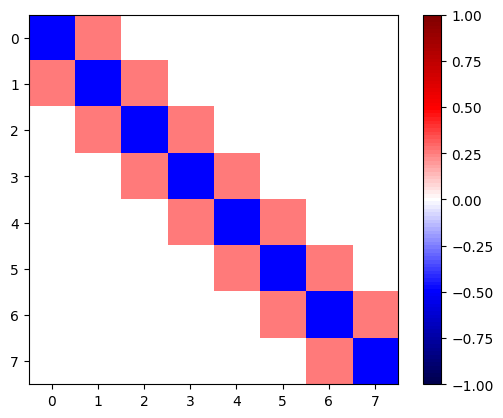

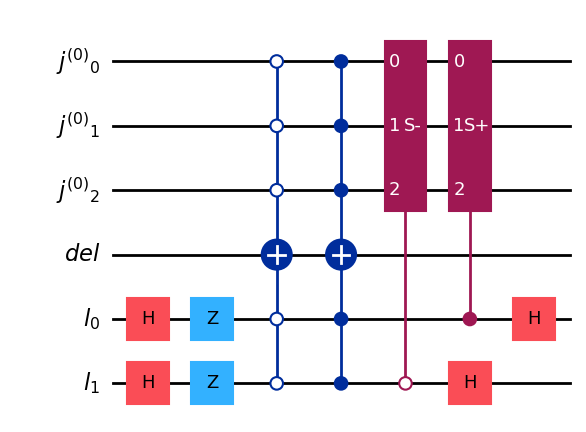

Boundary condition: periodic


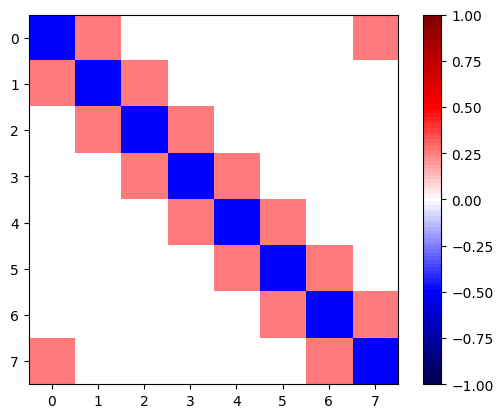

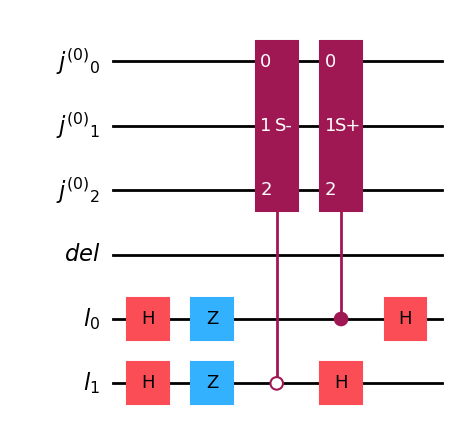

Boundary condition: neumann


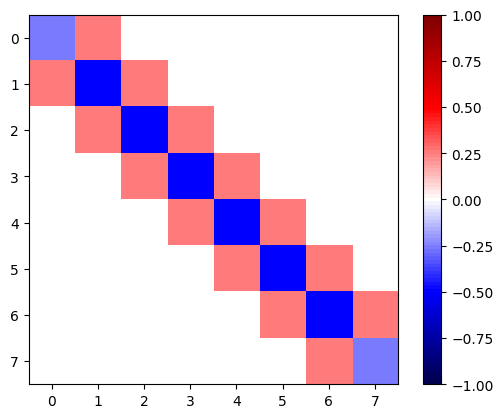

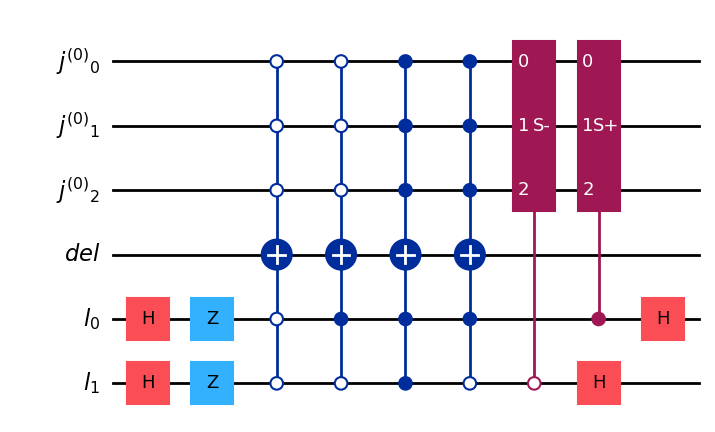

In [2]:
# Heat map and quantum circuit plots of our block encodings of 1D Laplacians
bcs = [("dirichlet",), ("periodic",), ("neumann",)]

for bc in bcs:
    print("Boundary condition:", bc[0])
    plot_heatmap([3], bcs=bc)
    qc = generate_laplacian_block_encoding([3], bcs=bc, save_unitary=False)
    fig = qc.draw(output="mpl")
    display(fig)

## Correctness check

In [3]:
# Manually computed Laplacian matrices
def lap1d_fd(n, h=1.0, bc="dirichlet"):
    """
    Build 1D second-order finite-difference  (standard 3-point centered (central) finite-difference discretization for the second derivative) 
    Laplacian for `n` grid points with spacing `h` and boundary condition `bc`.

    Parameters
    ----------
    n : int
        Number of grid points (nodes) along the 1D domain (>=1).
    h : float
        Grid spacing.
    bc : {'dirichlet','neumann','periodic'}
        Boundary condition type:
          - 'dirichlet' : u=0 at boundaries (standard tridiagonal).
          - 'neumann'   : zero-flux (one-sided treatment at endpoints).
          - 'periodic'  : wrap-around neighbors (circulant/tridiagonal with corners).

    Returns
    -------
    A : scipy.sparse.csr_matrix, shape (n,n)
        Sparse 1D Laplacian matrix (second derivative approximation) scaled by 1/h^2.
    """
    if n < 1:
        raise ValueError("n must be >= 1")

    main = -2.0 / (h * h)
    off = 1.0 / (h * h)

    # tridiagonal base (LIL for easy element assignment)
    A = sp.diags(
        [off * np.ones(n - 1), main * np.ones(n), off * np.ones(n - 1)],
        offsets=[-1, 0, 1],
        shape=(n, n),
        format="lil",
    )

    if bc == "periodic":
        # wrap-around entries
        if n >= 2:
            A[0, n - 1] = off
            A[n - 1, 0] = off
        else:
            # n == 1: Laplacian on single periodic point is zero
            A[0, 0] = 0.0

    elif bc == "neumann":
        if n == 1:
            A[0, 0] = 0.0
        else:
            # Neumann BC 
            A[0, 0] = -1.0 / (h * h)
            A[0, 1] =  1.0 / (h * h)

            A[n - 1, n - 2] =  1.0 / (h * h)
            A[n - 1, n - 1] = -1.0 / (h * h)

    else:
        # Dirichlet: standard tridiagonal (rows kept as is).
        pass

    return A.tocsr()


def generate_laplacian(shape, deltas=None, bcs=None, analytic_normalize=False):
    """
    Build separable FD Laplacian and optionally apply analytic normalization ().

    Parameters
    ----------
    shape : tuple of ints
        Number of grid points per axis (Nx, Ny, ...).
    deltas : tuple of floats or None
        Grid spacings per axis (hx, hy, ...). If None, uses 1.0 for each axis.
    bcs : str or tuple-of-str or None
        Boundary conditions per axis. If None, uses 'dirichlet' on all axes.
    analytic_normalize : bool
        If True, scale the assembled Laplacian by lambda_max = 4 * sum_i (1/h_i^2). 
        Returns (A_scaled, lambda_max). If False, returns A only. (We use the same analytical scaling factor as in the Sturm et al. 2025 paper.)

    Returns
    -------
    A or A_scaled
    """

    shape = tuple(shape)
    D = len(shape)
    if deltas is None:
        deltas = tuple([1.0] * D)
    else:
        deltas = tuple(deltas)

    if bcs is None:
        bcs = tuple(["dirichlet"] * D)
    elif isinstance(bcs, str):
        bcs = tuple([bcs] * D)
    else:
        bcs = tuple(bcs)

    # Build 1D operators
    ops_1d = [lap1d_fd(n, h, bc) for (n, h, bc) in zip(shape, deltas, bcs)]

    # Build Kronecker-sum: sum_k (I ⊗ ... ⊗ K_k ⊗ ... ⊗ I) # just like in the third reference paper (Sturm et al. 2015)
    total = None
    for axis, K in enumerate(ops_1d):
        # left identity: product of identity matrices for axes > axis
        kron_left = sp.eye(1, format="csr")
        for j in range(D - 1, axis, -1):
            kron_left = sp.kron(sp.eye(shape[j], format="csr"), kron_left, format="csr")

        # right identity: product for axes < axis
        kron_right = sp.eye(1, format="csr")
        for j in range(0, axis):
            kron_right = sp.kron(kron_right, sp.eye(shape[j], format="csr"), format="csr")

        term = sp.kron(kron_left, sp.kron(K, kron_right, format="csr"), format="csr")
        total = term if total is None else (total + term)

    A = total.tocsr()

    if analytic_normalize:  # again the same scaling factor as in the Sturm et al. 2025 paper
        # analytic lambda_max = 4 * sum_i (1 / h_i^2)
        lambda_max = 4.0 * sum((1.0 / (h * h)) for h in deltas)
        if lambda_max <= 0:
            raise ValueError("Computed lambda_max <= 0; check grid spacings.")
        A_scaled = A / lambda_max
        return A_scaled.tocsr()
    else:
        return A


In [4]:
# Checking correctness
bcs = [("dirichlet",), ("periodic",), ("neumann",)]
test_names = ["1D Dirichlet", "1D Periodic", "1D Neumann"]

for i, bc in enumerate(bcs):
    correct_mat = generate_laplacian((8,), (1,), bc, True).toarray()

    qc = generate_laplacian_block_encoding([3], bcs=bc)
    block_encoded_mat = get_circuit_unitary(qc, [3])

    if np.allclose(correct_mat, block_encoded_mat):
        print(f"--- PASSED ---\tTest {test_names[i]}")

    else:
        print(f"--- FAILED ---\tTest {test_names[i]}")

# 2D Laplacians
bcs = [("dirichlet", "periodic"), ("neumann", "neumann"), ("neumann", "dirichlet")]
test_names = ["2D DP", "2D NN", "2D ND"]

for i, bc in enumerate(bcs):
    correct_mat = generate_laplacian((8, 8), (1, 1), bc, True).toarray()

    qc = generate_laplacian_block_encoding([3, 3], bcs=bc)
    block_encoded_mat = get_circuit_unitary(qc, [3, 3])

    if np.allclose(correct_mat, block_encoded_mat):
        print(f"--- PASSED ---\tTest {test_names[i]}")

    else:
        print(f"--- FAILED ---\tTest {test_names[i]}")

# 3D Laplacians
bcs = [("dirichlet", "periodic", "neumann"), ("neumann", "neumann", "neumann")]
test_names = ["3D DPN", "3D NNN"]

for i, bc in enumerate(bcs):
    correct_mat = generate_laplacian((4, 4, 4), (1, 1, 1), bc, True).toarray()

    qc = generate_laplacian_block_encoding([2, 2, 2], bcs=bc)
    block_encoded_mat = get_circuit_unitary(qc, [2, 2, 2])

    if np.allclose(correct_mat, block_encoded_mat):
        print(f"--- PASSED ---\tTest {test_names[i]}")

    else:
        print(f"--- FAILED ---\tTest {test_names[i]}")

# 3D Laplacians with varied grid points and spacings
bcs = [("dirichlet", "periodic", "neumann")]
test_names = ["3D DPN with grid variations"]

for i, bc in enumerate(bcs):
    correct_mat = generate_laplacian((8, 4, 2), (1, 0.5, 0.2), bc, True).toarray()

    qc = generate_laplacian_block_encoding([3, 2, 1], deltas=[1, 0.5, 0.2], bcs=bc)
    block_encoded_mat = get_circuit_unitary(qc, [3, 2, 1])

    if np.allclose(correct_mat, block_encoded_mat):
        print(f"--- PASSED ---\tTest {test_names[i]}")

    else:
        print(f"--- FAILED ---\tTest {test_names[i]}")

NameError: name 'get_circuit_unitary' is not defined